Station -B -Data Cleaning & EDA

In [9]:
%pip install pandas numpy matplotlib seaborn

  Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl (9.7 MB)
Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl (12.6 MB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached seaborn-0.13.2-py3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importing

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

loading csv files

In [4]:
customers = pd.read_csv("data/csv/customers.csv")
orders = pd.read_csv("data/csv/orders.csv")
products = pd.read_csv("data/csv/products.csv")
support_tickets = pd.read_csv("data/csv/support_tickets.csv")

In [5]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Support Tickets:", support_tickets.shape)
customers.head()

Customers: (862, 12)
Orders: (3388, 10)
Products: (15, 6)
Support Tickets: (520, 8)


,customer_id,first_name,last_name,email,phone,city,state,signup_date,plan,age,last_active_date,churned
0,10001,Ryan,Diaz,ryan.diaz1@gmail.com,+1-898-412-8529,Boston,MA,2025-02-05,free,42.0,2026-08-18,0
1,10002,Maya,Brooks,maya.brooks2@yahoo.com,+1-629-420-1441,Chicago,IL,2025-03-12,plus,36.0,2026-08-21,0
2,10003,Maya,Bennett,maya.bennett3@outlook.com,+1-445-842-4470,Austin,TX,2025-10-14,pro,41.0,2026-08-24,0
3,10004,Arjun,Walker,arjun.walker4@gmail.com,+1-547-976-1578,Houston,TX,2025-11-28,free,18.0,2026-08-25,0
4,10005,Grace,Foster,grace.foster5@yahoo.com,+1-944-717-5118,Chicago,IL,2025-02-20,free,38.0,2026-08-30,0


In [6]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nORDERS")
print(orders.columns.tolist())

print("\nPRODUCTS")
print(products.columns.tolist())

print("\nSUPPORT TICKETS")
print(support_tickets.columns.tolist())

CUSTOMERS
['customer_id', 'first_name', 'last_name', 'email', 'phone', 'city', 'state', 'signup_date', 'plan', 'age', 'last_active_date', 'churned']

ORDERS
['order_id', 'customer_id', 'product_id', 'order_date', 'channel', 'quantity', 'unit_price', 'discount_pct', 'returned', 'status']

PRODUCTS
['product_id', 'sku', 'product_name', 'category', 'unit_cost', 'list_price']

SUPPORT TICKETS
['ticket_id', 'customer_id', 'order_id', 'created_at', 'ticket_type', 'priority', 'raw_message', 'resolved']


## Station B — Data Cleaning and EDA

The purpose of this section is to identify and handle data-quality issues in the PulseCart datasets before performing exploratory analysis.

Finding missing values

In [7]:
print("Customers missing values:")
display(customers.isnull().sum())

print("\nOrders missing values:")
display(orders.isnull().sum())

print("\nProducts missing values:")
display(products.isnull().sum())

print("\nSupport tickets missing values:")
display(support_tickets.isnull().sum())

Customers missing values:


customer_id          0
first_name           0
last_name            0
email                0
phone               17
city                 0
state                0
signup_date          0
plan                 0
age                 27
last_active_date     0
churned              0
dtype: int64


Orders missing values:


order_id        0
customer_id     0
product_id      0
order_date      0
channel         0
quantity        0
unit_price      0
discount_pct    0
returned        0
status          0
dtype: int64


Products missing values:


product_id      0
sku             0
product_name    0
category        0
unit_cost       0
list_price      0
dtype: int64


Support tickets missing values:


ticket_id       0
customer_id     0
order_id        0
created_at      0
ticket_type    31
priority        0
raw_message     0
resolved        0
dtype: int64

Duplicate emails

In [8]:
customers.duplicated().sum()

np.int64(0)

In [9]:
customers["email"].head(20)
duplicate_emails = customers[
    customers.duplicated(subset="email", keep=False)
].sort_values("email")

duplicate_emails


,customer_id,first_name,last_name,email,phone,city,state,signup_date,plan,age,last_active_date,churned
135,10136,Amara,Nguyen,amara.nguyen136@pulsecart-mail.com,+1-462-298-2104,Seattle,WA,2025-04-13,plus,36.0,2026-08-20,0
860,20011,amara,Nguyen,amara.nguyen136@pulsecart-mail.com,+1-462-298-2104,Seattle,WA,2025-04-13,plus,36.0,2026-08-20,0
851,20002,arjun,Ali,arjun.ali684@gmail.com,+1-970-719-8878,Atlanta,GA,2025-03-15,free,28.0,2026-08-20,0
683,10684,Arjun,Ali,arjun.ali684@gmail.com,+1-970-719-8878,Atlanta,GA,2025-03-15,free,28.0,2026-08-20,0
850,20001,diego,Foster,diego.foster827@gmail.com,+1-784-671-1605,Miami,FL,2025-02-07,plus,30.0,2026-08-21,0
826,10827,Diego,Foster,diego.foster827@gmail.com,+1-784-671-1605,Miami,FL,2025-02-07,plus,30.0,2026-08-21,0
859,20010,grace,Reyes,grace.reyes580@outlook.com,384-437-3845,Chicago,IL,2026-01-18,plus,20.0,2026-08-24,0
579,10580,Grace,Reyes,grace.reyes580@outlook.com,384-437-3845,Chicago,IL,2026-01-18,plus,20.0,2026-08-24,0
856,20007,leo,Rao,leo.rao325@yahoo.com,+1-622-886-2430,Atlanta,GA,2025-08-04,plus,18.0,2026-08-24,0
324,10325,Leo,Rao,leo.rao325@yahoo.com,+1-622-886-2430,Atlanta,GA,2025-08-04,plus,18.0,2026-08-24,0


In [10]:
print("Number of rows involved in duplicate emails:",
      duplicate_emails.shape[0])

print("Number of duplicated email values:",
      duplicate_emails["email"].nunique())

Number of rows involved in duplicate emails: 24
Number of duplicated email values: 12


cleaning


In [11]:
customers_clean = customers.copy()

customers_clean.shape

(862, 12)

In [12]:
customers_clean = customers_clean.drop_duplicates()

print("Original rows:", len(customers))
print("Rows after removing exact duplicates:", len(customers_clean))

Original rows: 862
Rows after removing exact duplicates: 862


In [13]:
customers_clean[
    customers_clean.duplicated(subset="email", keep=False)
].sort_values("email")

,customer_id,first_name,last_name,email,phone,city,state,signup_date,plan,age,last_active_date,churned
135,10136,Amara,Nguyen,amara.nguyen136@pulsecart-mail.com,+1-462-298-2104,Seattle,WA,2025-04-13,plus,36.0,2026-08-20,0
860,20011,amara,Nguyen,amara.nguyen136@pulsecart-mail.com,+1-462-298-2104,Seattle,WA,2025-04-13,plus,36.0,2026-08-20,0
851,20002,arjun,Ali,arjun.ali684@gmail.com,+1-970-719-8878,Atlanta,GA,2025-03-15,free,28.0,2026-08-20,0
683,10684,Arjun,Ali,arjun.ali684@gmail.com,+1-970-719-8878,Atlanta,GA,2025-03-15,free,28.0,2026-08-20,0
850,20001,diego,Foster,diego.foster827@gmail.com,+1-784-671-1605,Miami,FL,2025-02-07,plus,30.0,2026-08-21,0
826,10827,Diego,Foster,diego.foster827@gmail.com,+1-784-671-1605,Miami,FL,2025-02-07,plus,30.0,2026-08-21,0
859,20010,grace,Reyes,grace.reyes580@outlook.com,384-437-3845,Chicago,IL,2026-01-18,plus,20.0,2026-08-24,0
579,10580,Grace,Reyes,grace.reyes580@outlook.com,384-437-3845,Chicago,IL,2026-01-18,plus,20.0,2026-08-24,0
856,20007,leo,Rao,leo.rao325@yahoo.com,+1-622-886-2430,Atlanta,GA,2025-08-04,plus,18.0,2026-08-24,0
324,10325,Leo,Rao,leo.rao325@yahoo.com,+1-622-886-2430,Atlanta,GA,2025-08-04,plus,18.0,2026-08-24,0


dirty emails

In [14]:
def is_valid_email(email):
    if pd.isna(email):
        return False
    
    email = str(email).strip()
    
    pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"
    
    return bool(re.match(pattern, email))

In [15]:
customers_clean["email_valid"] = customers_clean["email"].apply(
    is_valid_email
)

customers_clean[["email", "email_valid"]].head(20)

,email,email_valid
0,ryan.diaz1@gmail.com,True
1,maya.brooks2@yahoo.com,True
2,maya.bennett3@outlook.com,True
3,arjun.walker4@gmail.com,True
4,grace.foster5@yahoo.com,True
5,kai.ali6@pulsecart-mail.com,True
6,jonah.shah7@outlook.com,True
7,zara.brooks8@outlook.com,True
8,amara.ortiz9@gmail.com,True
9,kai.brooks10@yahoo.com,True


In [16]:
invalid_emails = customers_clean[
    customers_clean["email_valid"] == False
]

invalid_emails[["email", "email_valid"]]

,email,email_valid
40,noahsilva41 at gmail.com,False
81,hannahnguyen82 at gmail.com,False
122,ryanwalker123 at gmail.com,False
163,ethankim164 at gmail.com,False
204,imanibrooks205 at gmail.com,False
245,gracereyes246 at gmail.com,False
286,hannahnguyen287 at gmail.com,False
327,noahfoster328 at gmail.com,False
368,chrispatel369 at gmail.com,False
409,diegopatel410 at gmail.com,False


In [17]:
print("Number of invalid emails:", len(invalid_emails))

Number of invalid emails: 20


Phone numbers cleaning

In [18]:
def clean_phone(phone):
    if pd.isna(phone):
        return np.nan
    
    digits = re.sub(r"\D", "", str(phone))
    
    if len(digits) == 10:
        return digits
    
    elif len(digits) > 10:
        return digits[-10:]
    
    return np.nan

In [19]:
customers_clean["phone_clean"] = customers_clean["phone"].apply(
    clean_phone
)

customers_clean[["phone", "phone_clean"]].head(20)

,phone,phone_clean
0,+1-898-412-8529,8984128529
1,+1-629-420-1441,6294201441
2,+1-445-842-4470,4458424470
3,+1-547-976-1578,5479761578
4,+1-944-717-5118,9447175118
5,+1-978-825-2179,9788252179
6,+1-590-750-4689,5907504689
7,+1-441-976-8678,4419768678
8,+1-492-756-9065,4927569065
9,+1-927-704-3745,9277043745


In [20]:
invalid_phones = customers_clean[
    customers_clean["phone_clean"].isna()
]

invalid_phones[["phone", "phone_clean"]]

,phone,phone_clean
52,NaN,NaN
105,NaN,NaN
158,NaN,NaN
211,NaN,NaN
264,NaN,NaN
317,NaN,NaN
370,NaN,NaN
423,NaN,NaN
476,NaN,NaN
529,NaN,NaN


In [21]:
print("Number of invalid phone numbers:", len(invalid_phones))

Number of invalid phone numbers: 17


Orphan orders

In [22]:
orphan_orders = orders[
    ~orders["customer_id"].isin(customers_clean["customer_id"])
]

orphan_orders.head()

,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status
3363,90001,39999,1011,2025-01-30,ios,1,24.0,5.0,0,delivered
3364,90002,39999,1015,2025-07-16,android,1,49.0,0.0,0,delivered
3365,90003,39999,1002,2025-12-14,web,1,149.0,0.0,0,delivered
3366,90004,39999,1006,2025-08-29,web,1,199.0,0.0,0,delivered
3367,90005,39999,1013,2026-03-12,web,1,34.0,0.0,1,returned


In [23]:
print("Number of orphan orders:", len(orphan_orders))

Number of orphan orders: 25


In [24]:
orphan_percentage = (
    len(orphan_orders) / len(orders)
) * 100

print(f"Orphan order percentage: {orphan_percentage:.2f}%")

Orphan order percentage: 0.74%


Impossible price

In [ ]:
product_prices = products[
    ["product_id", "product_name", "category", "list_price"]
].copy()

product_prices.head()

,product_id,product_name,category,list_price
0,1001,PulseBuds X,Audio,89.0
1,1002,Harbor Headphones,Audio,149.0
2,1003,Desk Speaker Mini,Audio,59.0
3,1004,FitBand 3,Wearables,79.0
4,1005,SleepRing Air,Wearables,129.0


In [26]:
orders_price_check = orders.merge(
    product_prices,
    on="product_id",
    how="left"
)

orders_price_check.head()

,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status,product_name,category,list_price
0,50000,10001,1012,2025-09-30,android,1,15.0,15.0,0,delivered,Cable Kit,Accessories,15.0
1,50001,10001,1003,2026-02-26,web,1,59.0,0.0,0,delivered,Desk Speaker Mini,Audio,59.0
2,50002,10001,1013,2025-10-03,web,1,34.0,0.0,0,delivered,BrewGo Travel Mug,Kitchen,34.0
3,50003,10002,1009,2025-11-16,ios,1,69.0,10.0,1,returned,Desk Lamp Pro,Home,69.0
4,50004,10002,1009,2026-07-15,ios,1,69.0,0.0,0,delivered,Desk Lamp Pro,Home,69.0


In [27]:
incorrect_prices = orders_price_check[
    orders_price_check["unit_price"] != orders_price_check["list_price"]
]

incorrect_prices[
    [
        "order_id",
        "product_id",
        "product_name",
        "unit_price",
        "list_price",
        "discount_pct",
        "status"
    ]
]

,order_id,product_id,product_name,unit_price,list_price,discount_pct,status
7,50007,1015,MealPrep Set,490.0,49.0,0.0,returned
218,50218,1015,MealPrep Set,490.0,49.0,0.0,delivered
429,50429,1001,PulseBuds X,890.0,89.0,0.0,delivered
640,50640,1012,Cable Kit,150.0,15.0,0.0,delivered
851,50851,1011,Laptop Sleeve 14,240.0,24.0,0.0,delivered
1062,51062,1015,MealPrep Set,490.0,49.0,0.0,delivered
1273,51273,1011,Laptop Sleeve 14,240.0,24.0,0.0,delivered
1484,51484,1015,MealPrep Set,490.0,49.0,0.0,delivered
1695,51695,1014,Blender Nano,890.0,89.0,5.0,delivered
1906,51906,1001,PulseBuds X,890.0,89.0,5.0,delivered


In [61]:
print("Number of incorrect price records:", len(incorrect_prices))

Number of incorrect price records: 16


In [28]:
incorrect_prices = incorrect_prices.copy()

incorrect_prices["price_difference"] = (
    incorrect_prices["unit_price"] -
    incorrect_prices["list_price"]
)

incorrect_prices[
    [
        "order_id",
        "product_id",
        "unit_price",
        "list_price",
        "price_difference"
    ]
]

,order_id,product_id,unit_price,list_price,price_difference
7,50007,1015,490.0,49.0,441.0
218,50218,1015,490.0,49.0,441.0
429,50429,1001,890.0,89.0,801.0
640,50640,1012,150.0,15.0,135.0
851,50851,1011,240.0,24.0,216.0
1062,51062,1015,490.0,49.0,441.0
1273,51273,1011,240.0,24.0,216.0
1484,51484,1015,490.0,49.0,441.0
1695,51695,1014,890.0,89.0,801.0
1906,51906,1001,890.0,89.0,801.0


In [29]:

orders_clean = orders.copy()

In [30]:
orders_clean = orders_clean.merge(
    products[["product_id", "list_price"]],
    on="product_id",
    how="left"
)

orders_clean.head()

,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status,list_price
0,50000,10001,1012,2025-09-30,android,1,15.0,15.0,0,delivered,15.0
1,50001,10001,1003,2026-02-26,web,1,59.0,0.0,0,delivered,59.0
2,50002,10001,1013,2025-10-03,web,1,34.0,0.0,0,delivered,34.0
3,50003,10002,1009,2025-11-16,ios,1,69.0,10.0,1,returned,69.0
4,50004,10002,1009,2026-07-15,ios,1,69.0,0.0,0,delivered,69.0


In [31]:
price_mismatch = (
    orders_clean["unit_price"] != orders_clean["list_price"]
)

orders_clean.loc[price_mismatch, "unit_price"] = (
    orders_clean.loc[price_mismatch, "list_price"]
)

In [32]:
remaining_incorrect_prices = orders_clean[
    orders_clean["unit_price"] != orders_clean["list_price"]
]

print(
    "Incorrect prices remaining:",
    len(remaining_incorrect_prices)
)

Incorrect prices remaining: 0


In [33]:
orders_clean[
    orders_clean["order_id"].isin(
        incorrect_prices["order_id"]
    )
][
    [
        "order_id",
        "product_id",
        "unit_price",
        "list_price",
        "discount_pct"
    ]
]

,order_id,product_id,unit_price,list_price,discount_pct
7,50007,1015,49.0,49.0,0.0
218,50218,1015,49.0,49.0,0.0
429,50429,1001,89.0,89.0,0.0
640,50640,1012,15.0,15.0,0.0
851,50851,1011,24.0,24.0,0.0
1062,51062,1015,49.0,49.0,0.0
1273,51273,1011,24.0,24.0,0.0
1484,51484,1015,49.0,49.0,0.0
1695,51695,1014,89.0,89.0,5.0
1906,51906,1001,89.0,89.0,5.0


In [34]:


invalid_product_prices = products[
    products["list_price"] <= 0
]

print(
    "Products with zero or negative list price:",
    len(invalid_product_prices)
)

invalid_product_prices

Products with zero or negative list price: 0


,product_id,sku,product_name,category,unit_cost,list_price


In [35]:


print("Total orders:", len(orders_clean))

print(
    "Orders with valid product price:",
    orders_clean["list_price"].notna().sum()
)

print(
    "Remaining price mismatches:",
    (
        orders_clean["unit_price"] !=
        orders_clean["list_price"]
    ).sum()
)

Total orders: 3388
Orders with valid product price: 3388
Remaining price mismatches: 0


In [38]:
price_cleaning_summary = pd.DataFrame({
    "Check": [
        "Zero/negative product prices",
        "Incorrect order unit prices",
        "Remaining price mismatches"
    ],
    
    "Count": [
        len(invalid_product_prices),
        len(incorrect_prices),
        (
            orders_clean["unit_price"] !=
            orders_clean["list_price"]
        ).sum()
    ]
})

price_cleaning_summary

,Check,Count
0,Zero/negative product prices,0
1,Incorrect order unit prices,16
2,Remaining price mismatches,0


city vs churn

In [40]:
city_summary = (
    customers_clean
    .groupby("city")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

city_summary["churn_rate"] = (
    city_summary["churn_rate"] * 100
)

city_summary = city_summary.sort_values(
    "churn_rate",
    ascending=False
)

city_summary

,city,total_customers,churned_customers,churn_rate
6,Houston,189,57,30.158730
3,Chicago,108,18,16.666667
9,Seattle,61,10,16.393443
4,Dallas,121,18,14.876033
0,Atlanta,86,10,11.627907
7,Miami,46,5,10.869565
1,Austin,95,10,10.526316
8,Phoenix,57,6,10.526316
2,Boston,40,4,10.000000
5,Denver,59,5,8.474576


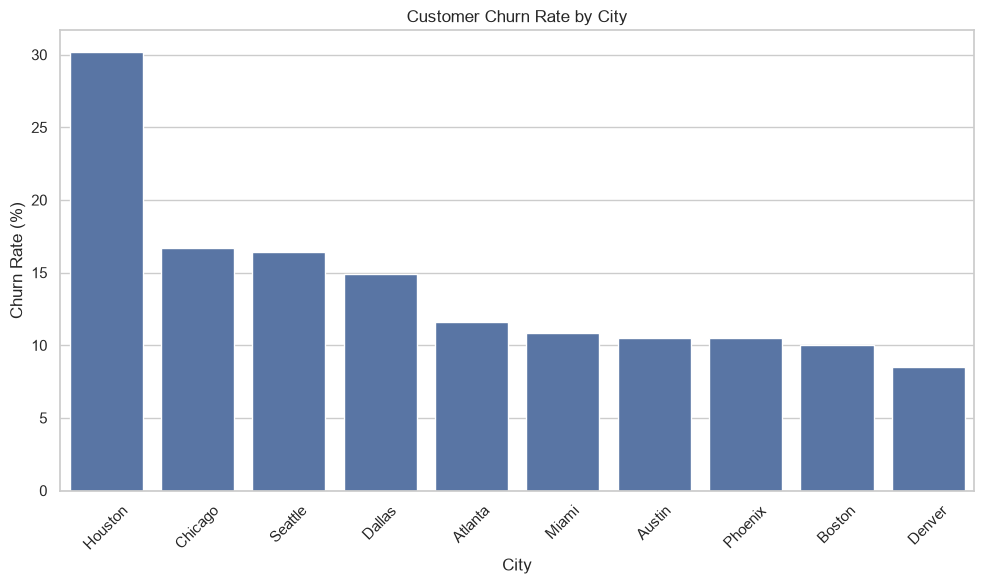

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_summary,
    x="city",
    y="churn_rate"
)

plt.title("Customer Churn Rate by City")
plt.xlabel("City")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Category vs return rate

In [42]:
orders_products = orders.merge(
    products[
        [
            "product_id",
            "product_name",
            "category",
            "list_price"
        ]
    ],
    on="product_id",
    how="left"
)

orders_products.head()

,order_id,customer_id,product_id,order_date,channel,quantity,unit_price,discount_pct,returned,status,product_name,category,list_price
0,50000,10001,1012,2025-09-30,android,1,15.0,15.0,0,delivered,Cable Kit,Accessories,15.0
1,50001,10001,1003,2026-02-26,web,1,59.0,0.0,0,delivered,Desk Speaker Mini,Audio,59.0
2,50002,10001,1013,2025-10-03,web,1,34.0,0.0,0,delivered,BrewGo Travel Mug,Kitchen,34.0
3,50003,10002,1009,2025-11-16,ios,1,69.0,10.0,1,returned,Desk Lamp Pro,Home,69.0
4,50004,10002,1009,2026-07-15,ios,1,69.0,0.0,0,delivered,Desk Lamp Pro,Home,69.0


In [43]:
print("Total orders:", len(orders_products))

print(
    "Orders without category:",
    orders_products["category"].isna().sum()
)

Total orders: 3388
Orders without category: 0


In [44]:
category_returns = (
    orders_products
    .groupby("category")
    .agg(
        total_orders=("order_id", "count"),
        returned_orders=("returned", "sum"),
        return_rate=("returned", "mean")
    )
    .reset_index()
)

category_returns["return_rate"] = (
    category_returns["return_rate"] * 100
)

category_returns

,category,total_orders,returned_orders,return_rate
0,Accessories,680,30,4.411765
1,Audio,646,36,5.572755
2,Home,653,52,7.963247
3,Kitchen,720,171,23.750000
4,Wearables,689,54,7.837446


In [45]:
category_returns

,category,total_orders,returned_orders,return_rate
0,Accessories,680,30,4.411765
1,Audio,646,36,5.572755
2,Home,653,52,7.963247
3,Kitchen,720,171,23.750000
4,Wearables,689,54,7.837446


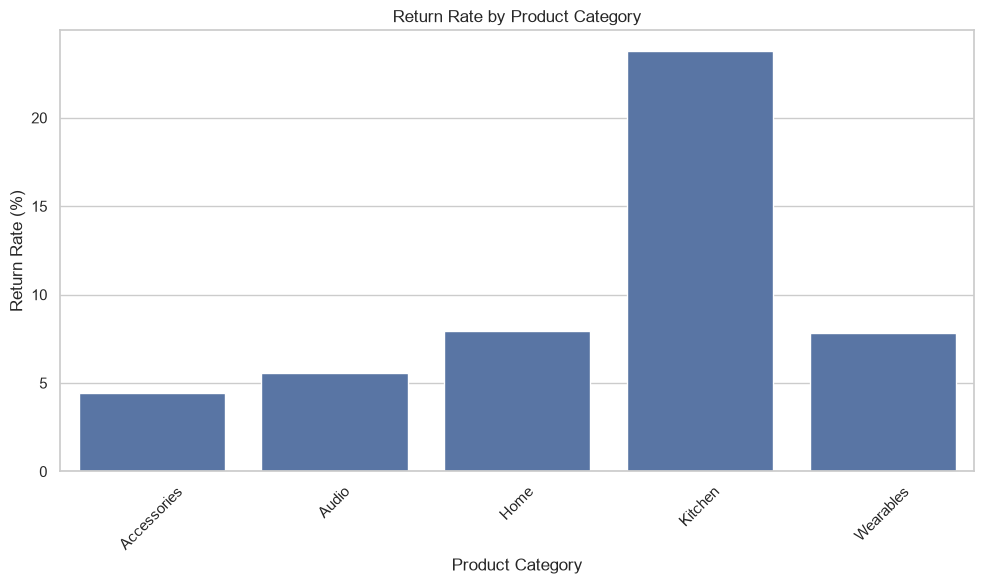

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_returns,
    x="category",
    y="return_rate"
)

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

 Price Distribution and Outlier Detection

In [47]:
products["list_price"].describe()

count     15.000000
mean      78.066667
std       52.258242
min       15.000000
25%       36.500000
50%       69.000000
75%      104.000000
max      199.000000
Name: list_price, dtype: float64

In [48]:
Q1 = products["list_price"].quantile(0.25)
Q3 = products["list_price"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 36.5
Q3: 104.0
IQR: 67.5


In [49]:
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -64.75
Upper Bound: 205.25


In [50]:
price_outliers = products[
    (products["list_price"] < lower_bound) |
    (products["list_price"] > upper_bound)
]

price_outliers[
    [
        "product_id",
        "product_name",
        "category",
        "list_price"
    ]
]

,product_id,product_name,category,list_price


In [51]:
print("Number of price outliers:", len(price_outliers))

Number of price outliers: 0


In [52]:
outlier_percentage = (
    len(price_outliers) / len(products)
) * 100

print(f"Price outlier percentage: {outlier_percentage:.2f}%")

Price outlier percentage: 0.00%


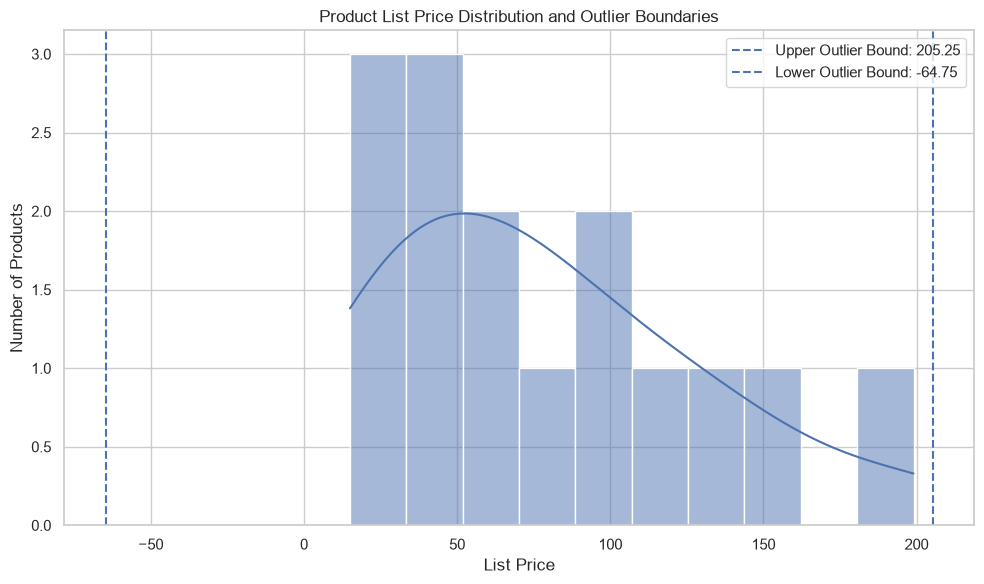

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=products,
    x="list_price",
    bins=10,
    kde=True
)

plt.axvline(
    upper_bound,
    linestyle="--",
    label=f"Upper Outlier Bound: {upper_bound:.2f}"
)

plt.axvline(
    lower_bound,
    linestyle="--",
    label=f"Lower Outlier Bound: {lower_bound:.2f}"
)

plt.title("Product List Price Distribution and Outlier Boundaries")
plt.xlabel("List Price")
plt.ylabel("Number of Products")

plt.legend()
plt.tight_layout()
plt.show()

In [54]:
price_outliers[
    [
        "product_id",
        "product_name",
        "category",
        "list_price"
    ]
].sort_values(
    "list_price",
    ascending=False
)

,product_id,product_name,category,list_price


#  Station C - Statistics

##	Measures of center and spread for order value and for customer order-count.

1. Order Value — Measures of Center and Spread

In [55]:
orders_clean["order_value"] = (
    orders_clean["quantity"]
    * orders_clean["unit_price"]
    * (1 - orders_clean["discount_pct"] / 100)
)

orders_clean["order_value"].describe()

count    3388.000000
mean       86.572565
std        66.730621
min        12.750000
25%        34.000000
50%        69.000000
75%       119.000000
max       597.000000
Name: order_value, dtype: float64

In [56]:
order_value_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum"
    ],
    "Value": [
        orders_clean["order_value"].mean(),
        orders_clean["order_value"].median(),
        orders_clean["order_value"].std(),
        orders_clean["order_value"].min(),
        orders_clean["order_value"].max()
    ]
})

order_value_stats

,Metric,Value
0,Mean,86.572565
1,Median,69.000000
2,Standard Deviation,66.730621
3,Minimum,12.750000
4,Maximum,597.000000


 Customer Order Count — Measures of Center and Spread

In [57]:
customer_order_count = (
    orders_clean
    .groupby("customer_id")
    .size()
    .reset_index(name="order_count")
)

customer_order_count.head()

,customer_id,order_count
0,10001,3
1,10002,7
2,10003,3
3,10004,7
4,10005,4


In [58]:
customer_order_count_stats = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum"
    ],
    "Value": [
        customer_order_count["order_count"].mean(),
        customer_order_count["order_count"].median(),
        customer_order_count["order_count"].std(),
        customer_order_count["order_count"].min(),
        customer_order_count["order_count"].max()
    ]
})

customer_order_count_stats

,Metric,Value
0,Mean,3.981199
1,Median,4.000000
2,Standard Deviation,2.275108
3,Minimum,1.000000
4,Maximum,25.000000


In [ ]:
2.	One association view (correlation or grouped rates) with a caution about causation.

In [59]:
customer_stats = customers_clean[
    ["customer_id", "churned"]
].merge(
    customer_order_count,
    on="customer_id",
    how="left"
)

customer_stats["order_count"] = (
    customer_stats["order_count"]
    .fillna(0)
)

customer_stats.head()

,customer_id,churned,order_count
0,10001,0,3.0
1,10002,0,7.0
2,10003,0,3.0
3,10004,0,7.0
4,10005,0,4.0


In [60]:
order_churn_correlation = customer_stats[
    ["order_count", "churned"]
].corr()

order_churn_correlation

,order_count,churned
order_count,1.000000,-0.271574
churned,-0.271574,1.000000


3.Hypothesis tests

Hypothesis Test 1 — City Churn Rate vs Everyone Else

In [61]:
selected_city = "Houston"

city_test_data = customers_clean.copy()

city_test_data["city_group"] = np.where(
    city_test_data["city"] == selected_city,
    selected_city,
    "Other cities"
)

city_test_data.groupby("city_group")["churned"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
city_group,,,
Houston,189,57,0.301587
Other cities,673,86,0.127786


In [63]:
%pip install statsmodels

  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached wrapt-2.4.1-cp312-cp312-win_amd64.whl.metadata (7.6 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.3 MB 10.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.3 MB 8.8 MB/s eta 0:00:01
   ------------ --------------------------- 3.7/11.3 MB 6.8 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.3 MB 6.8 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 4.1 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 4.1 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.3 MB 3.2 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.3 MB 3.2 MB/s eta 0:00:03
   --------------- ------------------------ 4.5/11.3 MB 2.4 MB/s eta 0:00:03
   --------------- ----------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
from statsmodels.stats.proportion import proportions_ztest

In [65]:
city_counts = (
    city_test_data
    .groupby("city_group")["churned"]
    .agg(["sum", "count"])
)

city_counts

,sum,count
city_group,,
Houston,57,189
Other cities,86,673


In [66]:
successes = city_counts["sum"].values
observations = city_counts["count"].values

z_stat, p_value = proportions_ztest(
    successes,
    observations
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 5.675610010480413
P-value: 1.3819529652528453e-08


City Churn Hypothesis Test

In [67]:
city_counts = (
    city_test_data
    .groupby("city_group")["churned"]
    .agg(["sum", "count"])
)

city_counts

,sum,count
city_group,,
Houston,57,189
Other cities,86,673


In [68]:
successes = city_counts["sum"].values
observations = city_counts["count"].values

z_stat, p_value = proportions_ztest(
    successes,
    observations
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 5.675610010480413
P-value: 1.3819529652528453e-08


In [69]:
city_rates = (
    city_test_data
    .groupby("city_group")["churned"]
    .mean()
    * 100
)

city_rates

city_group
Houston         30.158730
Other cities    12.778603
Name: churned, dtype: float64

In [70]:
city_rate_difference = (
    city_rates[selected_city]
    - city_rates["Other cities"]
)

print(
    f"Churn rate in {selected_city}: "
    f"{city_rates[selected_city]:.2f}%"
)

print(
    f"Churn rate in other cities: "
    f"{city_rates['Other cities']:.2f}%"
)

print(
    f"Difference: "
    f"{city_rate_difference:.2f} percentage points"
)

Churn rate in Houston: 30.16%
Churn rate in other cities: 12.78%
Difference: 17.38 percentage points


In [71]:
alpha = 0.05

if p_value < alpha:
    conclusion = (
        f"The churn rate in {selected_city} is statistically "
        f"different from the churn rate in other cities."
    )
else:
    conclusion = (
        f"There is not enough statistical evidence to conclude "
        f"that the churn rate in {selected_city} differs from "
        f"the churn rate in other cities."
    )

print(conclusion)

The churn rate in Houston is statistically different from the churn rate in other cities.


	Return rate for one category versus the other categories.

In [72]:
selected_category = category_returns.iloc[0]["category"]

print("Selected category:", selected_category)
print(
    "Return rate:",
    category_returns.iloc[0]["return_rate"]
)

Selected category: Accessories
Return rate: 4.411764705882353


In [73]:
category_test_data = orders_products.copy()

category_test_data["category_group"] = np.where(
    category_test_data["category"] == selected_category,
    selected_category,
    "Other categories"
)

category_test_data.groupby("category_group")["returned"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
category_group,,,
Accessories,680,30,0.044118
Other categories,2708,313,0.115583


In [74]:
category_counts = (
    category_test_data
    .groupby("category_group")["returned"]
    .agg(["sum", "count"])
)

successes = category_counts["sum"].values
observations = category_counts["count"].values

z_stat_category, p_value_category = proportions_ztest(
    successes,
    observations
)

print("Z-statistic:", z_stat_category)
print("P-value:", p_value_category)

Z-statistic: -5.5234203443747205
P-value: 3.324630552289587e-08


In [75]:
category_rates = (
    category_test_data
    .groupby("category_group")["returned"]
    .mean()
    * 100
)

category_rates

category_group
Accessories          4.411765
Other categories    11.558346
Name: returned, dtype: float64

In [76]:
category_rate_difference = (
    category_rates[selected_category]
    - category_rates["Other categories"]
)

print(
    f"Return rate for {selected_category}: "
    f"{category_rates[selected_category]:.2f}%"
)

print(
    f"Return rate for other categories: "
    f"{category_rates['Other categories']:.2f}%"
)

print(
    f"Difference: "
    f"{category_rate_difference:.2f} percentage points"
)

Return rate for Accessories: 4.41%
Return rate for other categories: 11.56%
Difference: -7.15 percentage points


In [77]:
alpha = 0.05

if p_value_category < alpha:
    category_conclusion = (
        f"The return rate for {selected_category} is "
        f"statistically different from the return rate "
        f"for other categories."
    )
else:
    category_conclusion = (
        f"There is not enough statistical evidence to conclude "
        f"that the return rate for {selected_category} differs "
        f"from the return rate for other categories."
    )

print(category_conclusion)

The return rate for Accessories is statistically different from the return rate for other categories.


City:

H0: The churn rate in Houston is equal to the churn rate in other cities.
Test used: Two-proportion z-test.
P-value: 1.38 × 10⁻⁸.
 Houston's churn rate is 30.16%, compared with 12.78% in other cities, a difference of 17.38 percentage points. This indicates that Houston has a substantially higher observed churn rate and may warrant further investigation. The result shows an association and does not establish that location causes churn.

Category:

H0: The return rate for Accessories is equal to the return rate for other categories.
Test used: Two-proportion z-test.
P-value: 3.32 × 10⁻⁸.
Accessories have a return rate of 4.41%, compared with 11.56% for other categories, a difference of 7.15 percentage points. This indicates that Accessories have a substantially lower observed return rate than other categories. The result shows an association and does not establish that category causes returns.
